# TEMPORAL FEATURE ENRICHMENT

Проверяем, добавляет ли короткая история causal-признаков и компактный regime context incremental value к текущему direct H1–H5 pipeline. Targets, split, test origins, model families и предыдущие configurations остаются неизменными.

## 1. Reused artifacts

Notebook не повторяет EDA, ARIMA/ARIMAX, CatBoost или широкий feature search. Предыдущий BASE загружается из сохранённых validation selections и test predictions.

In [1]:
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display

ROOT = Path.cwd().resolve()
if ROOT.name == 'notebooks': ROOT = ROOT.parent
if not (ROOT/'src').exists(): raise RuntimeError('Не найден корень репозитория')
if str(ROOT) not in sys.path: sys.path.insert(0, str(ROOT))
from src.temporal_feature_enrichment import plot_summary_and_paths, predict_next_5_rates, run_temporal_enrichment

required = [
 'reports/direct_multihorizon_model_selection.csv',
 'reports/direct_multihorizon_test_predictions.csv',
 'reports/direct_multihorizon_results.csv',
 'reports/temporal_split_horizons.csv',
 'data/features/fx_features_daily.parquet',
 'docs/base_feature_dictionary.md',
]
inventory = pd.DataFrame({'artifact':required,'exists':[(ROOT/p).exists() for p in required]})
display(inventory)
if not inventory.exists.all(): raise FileNotFoundError(inventory.loc[~inventory.exists,'artifact'].tolist())

,artifact,exists
0,reports/direct_multihorizon_model_selection.csv,True
1,reports/direct_multihorizon_test_predictions.csv,True
2,reports/direct_multihorizon_results.csv,True
3,reports/temporal_split_horizons.csv,True
4,data/features/fx_features_daily.parquet,True
5,docs/base_feature_dictionary.md,True


## 2. Experiment design

BASE — ровно прежние 15 causal features. ENRICHED — BASE плюс выбранные лаги и regime features. Для каждого `corridor × horizon` сохраняется previous model family и configuration; нового model zoo и tuning нет.

Target остаётся $\log(P_{T+h}/P_T)$, а прогноз восстанавливается как $P_T\exp(\hat y_h)$. **TEST LOCKED.**

In [2]:
run = run_temporal_enrichment(ROOT, make_plots=False)
print('Status:',run['status'])
print('Decision:',run['decision'])
print('Dataset:',run['dataset_path'].relative_to(ROOT))
print('Final features:',len(run['features']))

Status: PASS
Decision: EXACT_PATH_FORECASTING_PLATEAU
Dataset: data\features\fx_features_daily.parquet
Final features: 28


## 3. Causal lagged and regime features

Чтобы сохранить размер не более 30, лаги `+1,+2,+3` создаются только для четырёх рядов: `ret_1`, `vol_20`, `broad_rub_return_1`, `corridor_specific_return_1`. Они представляют собственное движение, волатильность, общий RUB-фактор и corridor-specific компонент.

Regimes: `vol_ratio_20_60`, `vol_20_change_3`, `momentum_spread`. Отрицательный `shift` не используется.

In [3]:
display(run['temporal_audit'])

,feature,kind,formula,source_feature,lag,available_at_t
0,ret_1_lag1,lag,ret_1.shift(+1),ret_1,1,True
1,ret_1_lag2,lag,ret_1.shift(+2),ret_1,2,True
2,ret_1_lag3,lag,ret_1.shift(+3),ret_1,3,True
3,vol_20_lag1,lag,vol_20.shift(+1),vol_20,1,True
4,vol_20_lag2,lag,vol_20.shift(+2),vol_20,2,True
5,vol_20_lag3,lag,vol_20.shift(+3),vol_20,3,True
6,broad_rub_return_1_lag1,lag,broad_rub_return_1.shift(+1),broad_rub_return_1,1,True
7,broad_rub_return_1_lag2,lag,broad_rub_return_1.shift(+2),broad_rub_return_1,2,True
8,broad_rub_return_1_lag3,lag,broad_rub_return_1.shift(+3),broad_rub_return_1,3,True
9,corridor_specific_return_1_lag1,lag,corridor_specific_return_1.shift(+1),corridor_specific_return_1,1,True


## 4. TRAIN-only cleanup

Проверяются exact duplicates, near-zero variance, missingness и `abs(Pearson correlation) >= 0.97`. BASE всегда рассматривается раньше новых полей, поэтому при redundancy сохраняется исходный признак. PCA/SHAP/VIF не используются.

In [4]:
display(run['cleanup'])
print('Used BASE:',sum((run['cleanup'].feature_group=='BASE') & run['cleanup'].used))
print('Used temporal/regime:',sum((run['cleanup'].feature_group=='NEW_TEMPORAL') & run['cleanup'].used))
print('Final feature list:',run['features'])

,feature,feature_group,available_at_t,used,train_missing_share,train_variance,exact_duplicate_of,correlated_with,correlation
0,ret_1,BASE,True,True,0.000756,0.000191,,,NaN
1,ret_3,BASE,True,True,0.002269,0.000644,,,NaN
2,ret_5,BASE,True,True,0.003782,0.001134,,,NaN
3,vol_5,BASE,True,True,0.003782,0.000105,,,NaN
4,vol_20,BASE,True,True,0.015129,0.000088,,,NaN
5,dist_min_20,BASE,True,True,0.014372,0.002602,,,NaN
6,favourability_percentile_90,BASE,True,True,0.068079,0.125108,,,NaN
7,dist_sma_20,BASE,True,True,0.014372,0.001494,,,NaN
8,broad_rub_return_1,BASE,True,True,0.000756,0.000162,,,NaN
9,broad_rub_return_3,BASE,True,True,0.002269,0.000620,,,NaN


Used BASE: 15
Used temporal/regime: 13
Final feature list: ['ret_1', 'ret_3', 'ret_5', 'vol_5', 'vol_20', 'dist_min_20', 'favourability_percentile_90', 'dist_sma_20', 'broad_rub_return_1', 'broad_rub_return_3', 'broad_rub_return_5', 'corridor_specific_return_1', 'return_sign_reversal_up', 'reversal_strength', 'near_min_reversal_010', 'ret_1_lag1', 'ret_1_lag2', 'ret_1_lag3', 'vol_20_lag3', 'broad_rub_return_1_lag1', 'broad_rub_return_1_lag2', 'broad_rub_return_1_lag3', 'corridor_specific_return_1_lag1', 'corridor_specific_return_1_lag2', 'corridor_specific_return_1_lag3', 'vol_ratio_20_60', 'vol_20_change_3', 'momentum_spread']


Два почти идентичных лага `vol_20_lag1/lag2` удалены из-за TRAIN correlation с текущим `vol_20`; остальные 13 новых полей сохранены. Итоговый ENRICHED set — 28 features.

## 5. Same temporal protocol

Используются те же 274 validation и 275 test origins на коридор. Purge между train/validation равен 5, между validation/test — 10 quote observations. Missing warm-up удаляется complete-case без backward fill.

In [5]:
display(run['splits'])
display(run['partition_audit'])

,corridor,train_start,train_end,validation_start,validation_end,test_start,test_end,n_train,n_validation,n_test,validation_origin_start,validation_origin_end,test_origin_start,test_origin_end,n_validation_origins,n_test_origins,n_right_censored_origins,forecast_horizons,primary_horizon,max_horizon
0,AMD_RUB,2019-01-10,2024-05-23,2024-05-24,2025-07-12,2025-07-15,2026-09-03,1322,283,284,2024-05-23,2025-06-28,2025-07-12,2026-08-20,274,275,10,"1,3,5,10",5,10
1,KGS_RUB,2019-01-10,2024-05-23,2024-05-24,2025-07-12,2025-07-15,2026-09-03,1322,283,284,2024-05-23,2025-06-28,2025-07-12,2026-08-20,274,275,10,"1,3,5,10",5,10
2,KZT_RUB,2019-01-10,2024-05-23,2024-05-24,2025-07-12,2025-07-15,2026-09-03,1322,283,284,2024-05-23,2025-06-28,2025-07-12,2026-08-20,274,275,10,"1,3,5,10",5,10
3,TJS_RUB,2019-01-10,2024-05-23,2024-05-24,2025-07-12,2025-07-15,2026-09-03,1322,283,284,2024-05-23,2025-06-28,2025-07-12,2026-08-20,274,275,10,"1,3,5,10",5,10
4,UZS_RUB,2019-01-10,2024-05-23,2024-05-24,2025-07-12,2025-07-15,2026-09-03,1322,283,284,2024-05-23,2025-06-28,2025-07-12,2026-08-20,274,275,10,"1,3,5,10",5,10


,corridor,partition,rows_before_complete_case,rows_after_complete_case,rows_lost,start,end,train_validation_purge_observations,validation_test_purge_observations
0,AMD_RUB,train,1317,1227,90,2019-05-24,2024-05-16,5,10
1,AMD_RUB,validation,274,274,0,2024-05-23,2025-06-28,5,10
2,AMD_RUB,refit,1600,1510,90,2019-05-24,2025-07-05,5,10
3,AMD_RUB,test,275,275,0,2025-07-12,2026-08-20,5,10
4,KGS_RUB,train,1317,1227,90,2019-05-24,2024-05-16,5,10
5,KGS_RUB,validation,274,274,0,2024-05-23,2025-06-28,5,10
6,KGS_RUB,refit,1600,1510,90,2019-05-24,2025-07-05,5,10
7,KGS_RUB,test,275,275,0,2025-07-12,2026-08-20,5,10
8,KZT_RUB,train,1317,1227,90,2019-05-24,2024-05-16,5,10
9,KZT_RUB,validation,274,274,0,2024-05-23,2025-06-28,5,10


## 6. Fixed previous models and validation comparison

Previous Ridge/Gradient Boosting family и параметры выбираются из уже сохранённого validation experiment. Та же family/configuration обучается на ENRICHED features. Таблица показывает, какой feature set лучше на validation; test для этого решения не читается.

In [6]:
display(run['previous_selection'])
display(run['validation'])
print(run['validation'].validation_preferred_feature_set.value_counts())

,corridor,horizon,model_family,params,base_validation_MAE,base_validation_RMSE,DA,n_validation
0,AMD_RUB,1,DIRECT_RIDGE,"{""alpha"": 0.1}",0.001672,0.002445,0.562044,274
1,AMD_RUB,2,DIRECT_RIDGE,"{""alpha"": 1.0}",0.002703,0.003876,0.580292,274
2,AMD_RUB,3,DIRECT_GRADIENT_BOOSTING,"{""learning_rate"": 0.03, ""max_depth"": 2, ""n_est...",0.003422,0.004862,0.459854,274
3,AMD_RUB,4,DIRECT_GRADIENT_BOOSTING,"{""learning_rate"": 0.03, ""max_depth"": 2, ""n_est...",0.003873,0.005531,0.489051,274
4,AMD_RUB,5,DIRECT_GRADIENT_BOOSTING,"{""learning_rate"": 0.03, ""max_depth"": 2, ""n_est...",0.004279,0.006168,0.481752,274
5,KGS_RUB,1,DIRECT_RIDGE,"{""alpha"": 100.0}",0.007399,0.010824,0.580292,274
6,KGS_RUB,2,DIRECT_GRADIENT_BOOSTING,"{""learning_rate"": 0.05, ""max_depth"": 3, ""n_est...",0.011979,0.017264,0.540146,274
7,KGS_RUB,3,DIRECT_RIDGE,"{""alpha"": 100.0}",0.015179,0.020734,0.510949,274
8,KGS_RUB,4,DIRECT_GRADIENT_BOOSTING,"{""learning_rate"": 0.03, ""max_depth"": 2, ""n_est...",0.017349,0.024605,0.419708,274
9,KGS_RUB,5,DIRECT_RIDGE,"{""alpha"": 100.0}",0.018788,0.026219,0.529197,274


,corridor,horizon,model_family,params,base_validation_MAE,enriched_validation_MAE,enriched_validation_RMSE,enriched_validation_DA,validation_preferred_feature_set,selection_used_test
0,AMD_RUB,1,DIRECT_RIDGE,"{""alpha"": 0.1}",0.001672,0.001668,0.002422,0.587591,ENRICHED,False
1,AMD_RUB,2,DIRECT_RIDGE,"{""alpha"": 1.0}",0.002703,0.002682,0.003850,0.602190,ENRICHED,False
2,AMD_RUB,3,DIRECT_GRADIENT_BOOSTING,"{""learning_rate"": 0.03, ""max_depth"": 2, ""n_est...",0.003422,0.003451,0.005036,0.459854,BASE,False
3,AMD_RUB,4,DIRECT_GRADIENT_BOOSTING,"{""learning_rate"": 0.03, ""max_depth"": 2, ""n_est...",0.003873,0.003903,0.005643,0.492701,BASE,False
4,AMD_RUB,5,DIRECT_GRADIENT_BOOSTING,"{""learning_rate"": 0.03, ""max_depth"": 2, ""n_est...",0.004279,0.004359,0.006468,0.492701,BASE,False
5,KGS_RUB,1,DIRECT_RIDGE,"{""alpha"": 100.0}",0.007399,0.007520,0.010901,0.540146,BASE,False
6,KGS_RUB,2,DIRECT_GRADIENT_BOOSTING,"{""learning_rate"": 0.05, ""max_depth"": 3, ""n_est...",0.011979,0.012026,0.017075,0.478102,BASE,False
7,KGS_RUB,3,DIRECT_RIDGE,"{""alpha"": 100.0}",0.015179,0.015210,0.020536,0.525547,BASE,False
8,KGS_RUB,4,DIRECT_GRADIENT_BOOSTING,"{""learning_rate"": 0.03, ""max_depth"": 2, ""n_est...",0.017349,0.017049,0.023992,0.441606,ENRICHED,False
9,KGS_RUB,5,DIRECT_RIDGE,"{""alpha"": 100.0}",0.018788,0.019028,0.026221,0.514599,BASE,False


validation_preferred_feature_set
BASE        18
ENRICHED     7
Name: count, dtype: int64


## 7. Unified enriched forecast vector

In [7]:
corridor=sorted(run['models'])[0]
row=run['partitions'][corridor]['test'].iloc[0]
print(corridor,row.date.date())
print(predict_next_5_rates(row,corridor,run['models'],run['features']))

AMD_RUB 2025-07-12
[0.2027639138794786, 0.20267506740038882, 0.20314226248581455, 0.20346013090647774, 0.20392253921791917]


## 8. Locked-test predictions and metrics

Все metrics используют прежние формулы в rate space: MAE/RMSE/DA H1...H5, Path MAE, Future-Best MAE и Regret MAE. Actual future используется только как target/evaluation.

In [8]:
required=['corridor','date','rate_t',*[f'predicted_rate_h{h}' for h in range(1,6)],*[f'actual_rate_h{h}' for h in range(1,6)],'predicted_future_best_5','actual_future_best_5','predicted_regret_5','actual_regret_5']
display(run['predictions'][required].head())
display(run['results'])

,corridor,date,rate_t,predicted_rate_h1,predicted_rate_h2,predicted_rate_h3,predicted_rate_h4,predicted_rate_h5,actual_rate_h1,actual_rate_h2,actual_rate_h3,actual_rate_h4,actual_rate_h5,predicted_future_best_5,actual_future_best_5,predicted_regret_5,actual_regret_5
0,AMD_RUB,2025-07-12,0.202874,0.202764,0.202675,0.203142,0.203460,0.203923,0.204020,0.202953,0.203038,0.203545,0.203818,0.202675,0.202953,0.000981,0.000000
1,AMD_RUB,2025-07-15,0.204020,0.203966,0.203742,0.204397,0.204794,0.205226,0.202953,0.203038,0.203545,0.203818,0.204068,0.203742,0.202953,0.001363,0.005230
2,AMD_RUB,2025-07-16,0.202953,0.202606,0.202812,0.203059,0.203098,0.203314,0.203038,0.203545,0.203818,0.204068,0.203371,0.202606,0.203038,0.001711,0.000000
3,AMD_RUB,2025-07-17,0.203038,0.203077,0.203166,0.203223,0.203366,0.203514,0.203545,0.203818,0.204068,0.203371,0.204344,0.203077,0.203371,0.000000,0.000000
4,AMD_RUB,2025-07-18,0.203545,0.203809,0.204020,0.203851,0.204008,0.204091,0.203818,0.204068,0.203371,0.204344,0.205510,0.203809,0.203371,0.000000,0.000855


,corridor,model,MAE_H1,RMSE_H1,DA_H1,MAE_H2,RMSE_H2,DA_H2,MAE_H3,RMSE_H3,...,MAE_H5_status,Path_MAE_5_ratio,Path_MAE_5_improvement_pct,Path_MAE_5_status,Future_Best_MAE_5_ratio,Future_Best_MAE_5_improvement_pct,Future_Best_MAE_5_status,Regret_MAE_5_ratio,Regret_MAE_5_improvement_pct,Regret_MAE_5_status
0,AMD_RUB,ENRICHED,0.001337,0.001762,0.574545,0.002008,0.002704,0.614545,0.002644,0.003372,...,PRACTICALLY_TIED,1.000111,-0.011056,WORSE,0.997842,0.215777,PRACTICALLY_TIED,0.993880,0.612032,PRACTICALLY_TIED
1,KGS_RUB,ENRICHED,0.005910,0.007713,0.509091,0.008754,0.011625,0.600000,0.011744,0.014987,...,WORSE,1.010586,-1.058621,WORSE,1.007441,-0.744103,WORSE,1.003935,-0.393498,WORSE
2,KZT_RUB,ENRICHED,0.001291,0.001699,0.523636,0.002018,0.002569,0.465455,0.002407,0.003107,...,WORSE,1.026328,-2.632754,WORSE,1.033951,-3.395087,WORSE,1.036302,-3.630179,WORSE
3,TJS_RUB,ENRICHED,0.054620,0.073489,0.549091,0.082417,0.108973,0.625455,0.114030,0.146305,...,IMPROVED,0.997744,0.225644,PRACTICALLY_TIED,0.993356,0.664431,PRACTICALLY_TIED,0.993405,0.659543,PRACTICALLY_TIED
4,UZS_RUB,ENRICHED,0.000047,0.000060,0.610909,0.000073,0.000095,0.574545,0.000095,0.000120,...,WORSE,1.000673,-0.067316,WORSE,0.995433,0.456718,PRACTICALLY_TIED,0.992903,0.709691,PRACTICALLY_TIED


## 9. Practical comparison

Положительный прирост меньше 1% — `PRACTICALLY_TIED`, не меньше 1% — `IMPROVED`, ухудшение — `WORSE`.

In [9]:
columns=['corridor','MAE_H5_improvement_pct','MAE_H5_status','Path_MAE_5_improvement_pct','Path_MAE_5_status','Future_Best_MAE_5_improvement_pct','Future_Best_MAE_5_status','Regret_MAE_5_improvement_pct','Regret_MAE_5_status']
display(run['results'][columns])

,corridor,MAE_H5_improvement_pct,MAE_H5_status,Path_MAE_5_improvement_pct,Path_MAE_5_status,Future_Best_MAE_5_improvement_pct,Future_Best_MAE_5_status,Regret_MAE_5_improvement_pct,Regret_MAE_5_status
0,AMD_RUB,0.385527,PRACTICALLY_TIED,-0.011056,WORSE,0.215777,PRACTICALLY_TIED,0.612032,PRACTICALLY_TIED
1,KGS_RUB,-0.946360,WORSE,-1.058621,WORSE,-0.744103,WORSE,-0.393498,WORSE
2,KZT_RUB,-3.927721,WORSE,-2.632754,WORSE,-3.395087,WORSE,-3.630179,WORSE
3,TJS_RUB,1.204648,IMPROVED,0.225644,PRACTICALLY_TIED,0.664431,PRACTICALLY_TIED,0.659543,PRACTICALLY_TIED
4,UZS_RUB,-0.158834,WORSE,-0.067316,WORSE,0.456718,PRACTICALLY_TIED,0.709691,PRACTICALLY_TIED


## 10. Feature signal

Для Gradient Boosting используются `feature_importances_`, для Ridge — абсолютные standardized coefficients. Ranking строится отдельно по corridor и family, поскольку шкалы двух importance нельзя смешивать.

In [10]:
top_signal=run['signal'].loc[run['signal']['rank']<=10]
display(top_signal)
useful=top_signal.loc[top_signal.is_temporal_enrichment,'feature'].value_counts()
display(useful.rename('top10_occurrences').to_frame())

,corridor,model_family,feature,is_temporal_enrichment,importance,rank
23,AMD_RUB,DIRECT_GRADIENT_BOOSTING,vol_20,False,0.202573,1
22,AMD_RUB,DIRECT_GRADIENT_BOOSTING,reversal_strength,False,0.183417,2
25,AMD_RUB,DIRECT_GRADIENT_BOOSTING,vol_20_lag3,True,0.171775,3
24,AMD_RUB,DIRECT_GRADIENT_BOOSTING,vol_20_change_3,True,0.085511,4
27,AMD_RUB,DIRECT_GRADIENT_BOOSTING,vol_ratio_20_60,True,0.068717,5
...,...,...,...,...,...,...
236,UZS_RUB,DIRECT_RIDGE,favourability_percentile_90,False,0.001780,6
237,UZS_RUB,DIRECT_RIDGE,momentum_spread,True,0.001283,7
244,UZS_RUB,DIRECT_RIDGE,ret_5,False,0.000947,8
238,UZS_RUB,DIRECT_RIDGE,near_min_reversal_010,False,0.000911,9


,top10_occurrences
feature,
vol_20_lag3,7
vol_20_change_3,6
broad_rub_return_1_lag1,4
broad_rub_return_1_lag2,3
momentum_spread,3
vol_ratio_20_60,2
ret_1_lag2,2
ret_1_lag1,2
corridor_specific_return_1_lag2,2


## 11. Minimal visualizations

Один summary plot Path MAE и максимум один representative path на corridor.

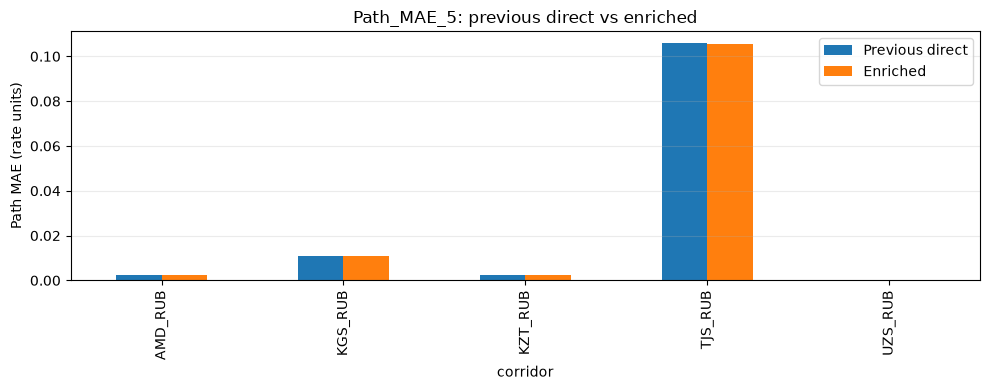

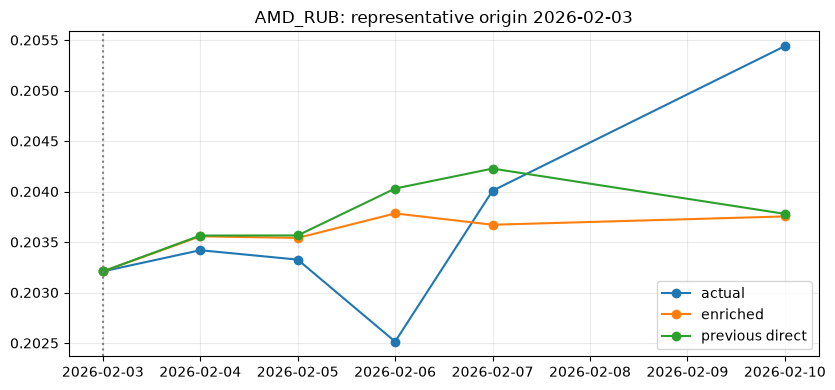

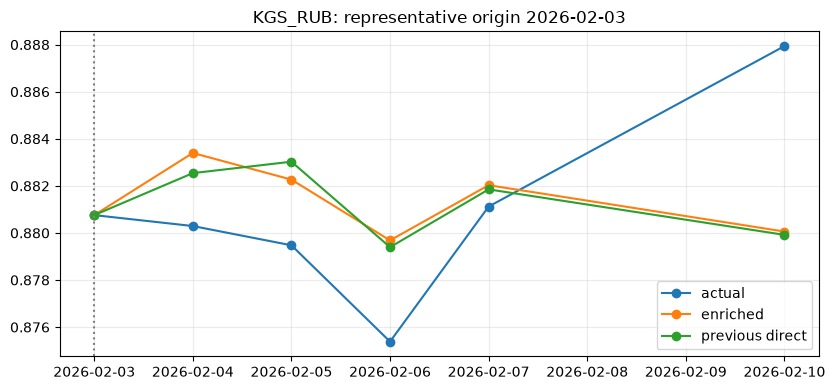

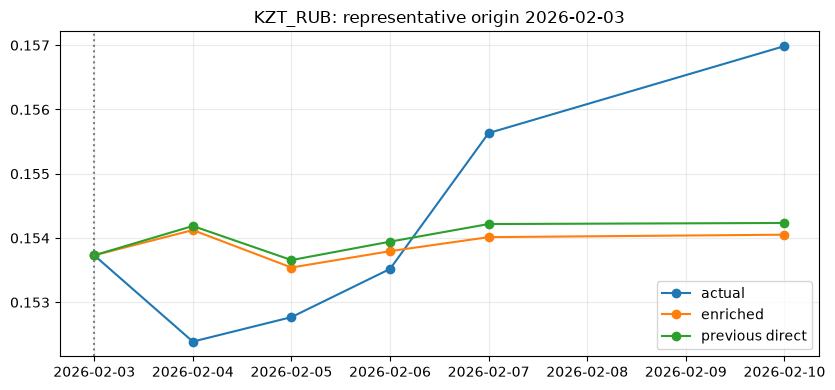

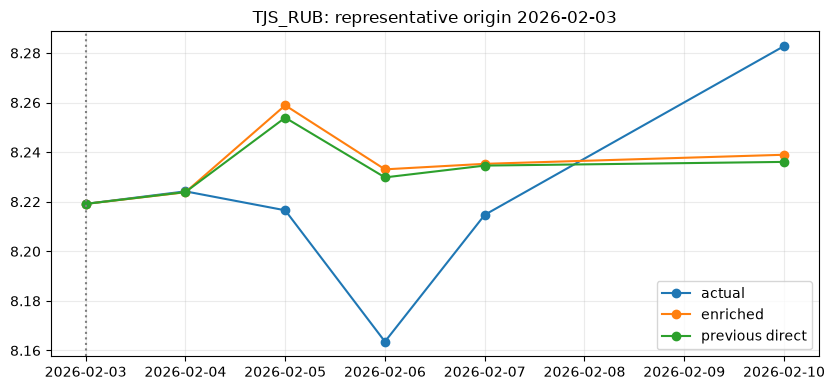

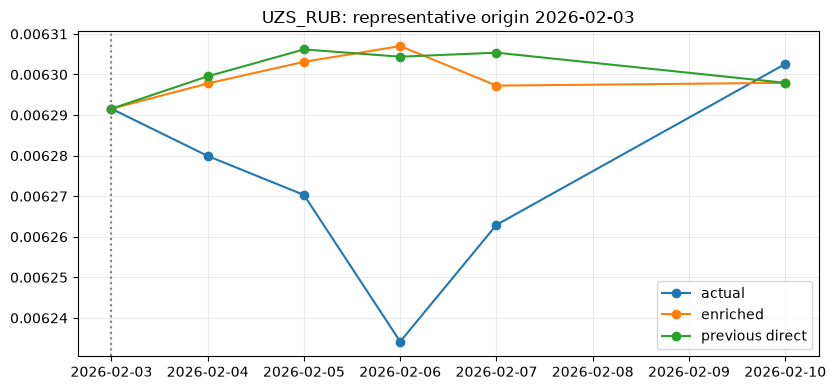

In [11]:
plot_summary_and_paths(run['predictions'],run['previous_predictions'],run['results'])

## 12. Leakage check

In [12]:
display(run['leakage'])
leakage_status='PASS' if run['leakage'].passed.all() else 'FAIL'
print('TEMPORAL ENRICHMENT LEAKAGE CHECK:',leakage_status)

,check,passed
0,all lagged features use shift(+N),True
1,no future features,True
2,same temporal split,True
3,same test origins,True
4,validation-only model selection,True
5,test locked,True
6,purge >= 5,True
7,targets only used as y,True


TEMPORAL ENRICHMENT LEAKAGE CHECK: PASS


## 13. Final decision

In [13]:
r=run['results']
useful_features=top_signal.loc[top_signal.is_temporal_enrichment,'feature'].value_counts().index.tolist()
print('TEMPORAL FEATURE ENRICHMENT:',run['status'])
print(f"ENRICHED improves MAE_H5 >=1%: {(r.MAE_H5_improvement_pct>=1).sum()}/5 corridors")
print(f"ENRICHED improves Path_MAE_5 >=1%: {(r.Path_MAE_5_improvement_pct>=1).sum()}/5")
print(f"ENRICHED improves Future_Best_MAE_5 >=1%: {(r.Future_Best_MAE_5_improvement_pct>=1).sum()}/5")
print(f"ENRICHED improves Regret_MAE_5 >=1%: {(r.Regret_MAE_5_improvement_pct>=1).sum()}/5")
print(f"Average Path_MAE improvement: {r.Path_MAE_5_improvement_pct.mean():.3f}%")
print('Useful lag/regime features:',useful_features)
print('Leakage:',leakage_status)
print('Decision gate:',run['decision'])
if run['decision']=='EXACT_PATH_FORECASTING_PLATEAU':
    print('Recommendation: stop exact H1...H5 complexity and move to direct future_best_5 or regret_5 prediction.')
print('Files:')
print('notebooks/05_temporal_feature_enrichment.ipynb')
for key in ('results','predictions','report'): print(run['outputs'][key].relative_to(ROOT).as_posix())

TEMPORAL FEATURE ENRICHMENT: PASS
ENRICHED improves MAE_H5 >=1%: 1/5 corridors
ENRICHED improves Path_MAE_5 >=1%: 0/5
ENRICHED improves Future_Best_MAE_5 >=1%: 0/5
ENRICHED improves Regret_MAE_5 >=1%: 0/5
Average Path_MAE improvement: -0.709%
Useful lag/regime features: ['vol_20_lag3', 'vol_20_change_3', 'broad_rub_return_1_lag1', 'broad_rub_return_1_lag2', 'momentum_spread', 'vol_ratio_20_60', 'ret_1_lag2', 'ret_1_lag1', 'corridor_specific_return_1_lag2', 'corridor_specific_return_1_lag3', 'corridor_specific_return_1_lag1']
Leakage: PASS
Decision gate: EXACT_PATH_FORECASTING_PLATEAU
Recommendation: stop exact H1...H5 complexity and move to direct future_best_5 or regret_5 prediction.
Files:
notebooks/05_temporal_feature_enrichment.ipynb
reports/temporal_enrichment_results.csv
reports/temporal_enrichment_test_predictions.csv
reports/temporal_enrichment_report.md
